# Validation on the lognormal simulation

The result data used in this notebook is generated by running `func_00.py`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from specs import *
from meer21cm import MockSimulation
from func_00 import *
from meer21cm.telescope import dish_beam_sigma
from matplotlib.colors import LogNorm
from astropy.cosmology import Planck18
import matplotlib.ticker as tck

In [2]:
karr = get_k_modes()
kperp, kpara, kmode, kvec = karr

In [3]:
k_xy_sel = (
    (np.abs(kvec[0])<0.04)[:,None,None] 
    * (np.abs(kvec[1])<0.04)[None,:,None]
    * (np.abs(kvec[2])<10)[None,None,:]
)
k_xy_sel[0] = 0.0
k_xy_sel[:,0] = 0.0
k_xy_sel[:,:,0] = 0.0

In [4]:
k_cy_sel = np.ones_like(kmode)
k_cy_sel[0] = 0.0
k_cy_sel[:,0] = 0.0
k_cy_sel[:,:,0] = 0.0

In [5]:
data = np.load('/scratch3/users/ztchen/validation/00.npz')

In [6]:
phimock_cy = get_cy(data['pdata3d_arr'],karr,weights=k_cy_sel)
pmodelcy_arr = get_cy(data['phimod3d_arr'],karr,weights=k_cy_sel)
pgmock_cy = get_cy(data['pg3d_arr'],karr,weights=k_cy_sel)
pgmodcy_arr = get_cy(data['pgmod3d_arr'],karr,weights=k_cy_sel)
pcrossmock_cy = get_cy(data['pcross3d_arr'],karr,weights=k_cy_sel)
pcrossmodcy_arr = get_cy(data['pcrossmod3d_arr'],karr,weights=k_cy_sel)

/users/ztchen/meer21cm/src/meer21cm/power.py:2067: RuntimeWarning: invalid value encountered in divide
  pscy = pscy / np.sum(weights, 0)[None]


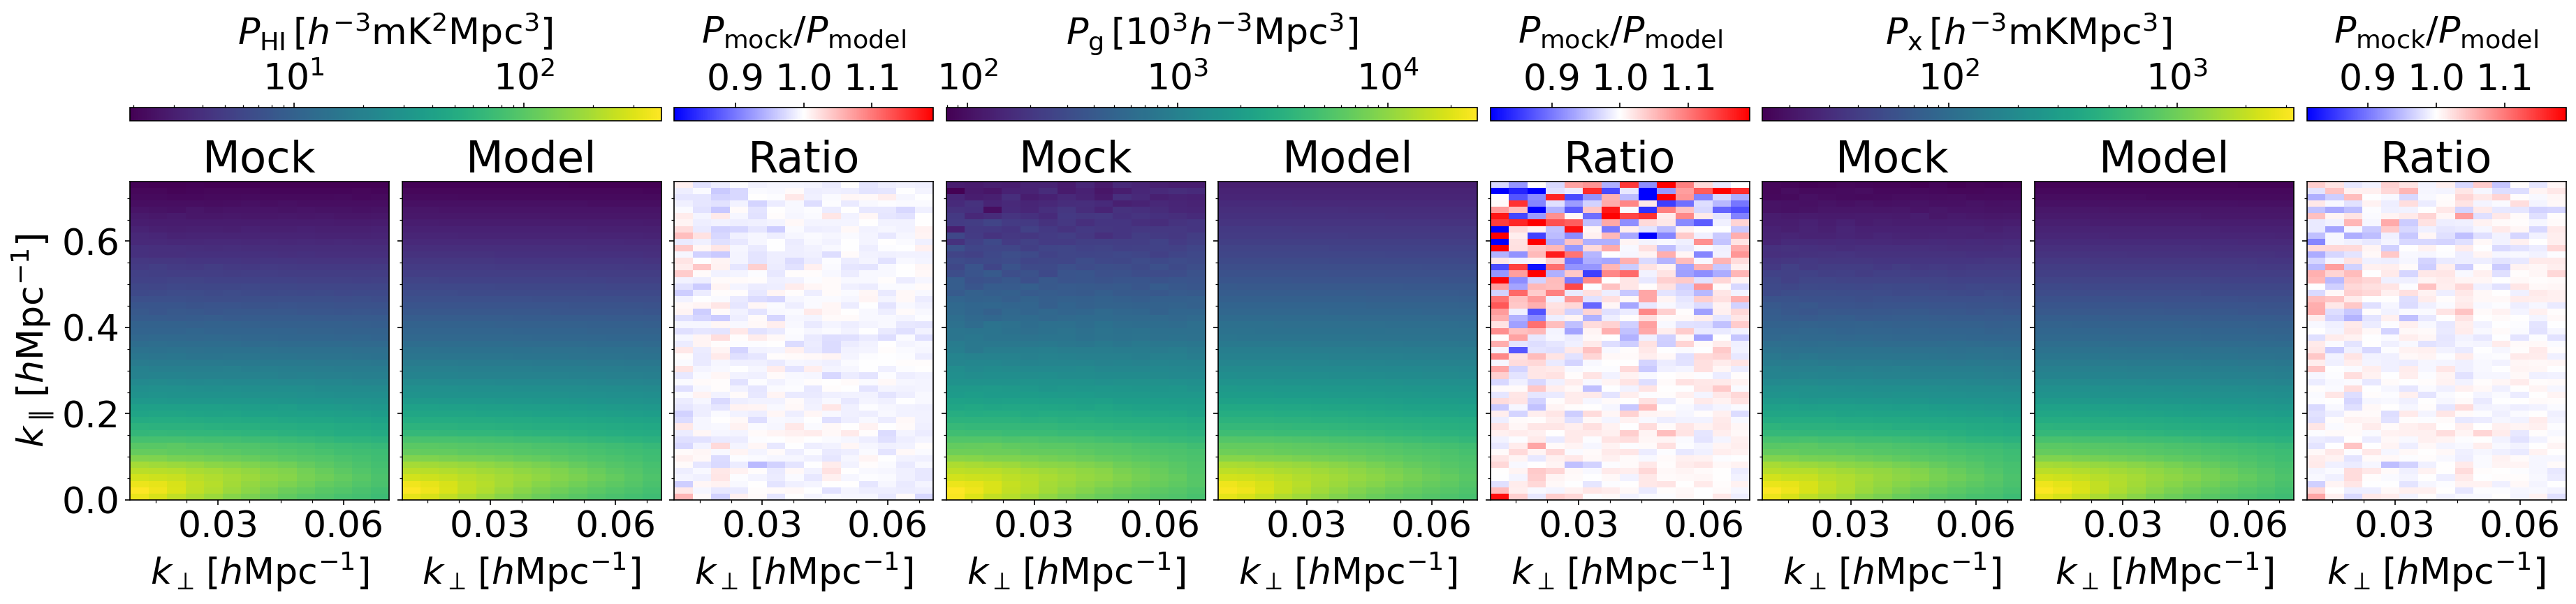

In [7]:
plt.rcParams['font.size'] = 25
fig, axes = plt.subplots(1, 9,figsize=(30,5),gridspec_kw={'wspace':0.05},dpi=150)
pmockarr = [phimock_cy*1e6,pgmock_cy,pcrossmock_cy*1e3]
pmodelarr = [pmodelcy_arr*1e6,pgmodcy_arr,pcrossmodcy_arr*1e3]
pmockarr = np.array(pmockarr) * Planck18.h**3
pmodelarr = np.array(pmodelarr) * Planck18.h**3
ylabelarr= [
    r'$P_{\rm HI}\,[ h^{-3} {\rm mK^2 Mpc^3}]$',
    r'$P_{\rm g}\,[ 10^3 h^{-3}{\rm Mpc^3}]$',
    r'$P_{\rm x}\,[h^{-3} {\rm mK Mpc^3}]$',
]
for i in range(3):
    xbins = kperpbins / Planck18.h
    ybins = kparabins / Planck18.h
    pdatacy = pmockarr[i]
    pmodcy = pmodelarr[i]
    arr = np.array([
        (pdatacy.T),
        (pmodcy.T),
    ])
    vmin = np.nanmin(arr)
    vmax = np.nanmax(arr)
    axes[0+i*3].pcolormesh(
        xbins,
        ybins,
        (pdatacy.T),
        norm=LogNorm(vmin=vmin, vmax=vmax)
    )
    if i>0:
        axes[0+i*3].set_yticklabels([])
    else:
        axes[0+i*3].set_ylabel(r'$k_\parallel\,[h{\rm Mpc^{-1}}]$')
    axes[0+i*3].set_title(r'Mock')
    
    im = axes[1+i*3].pcolormesh(
        xbins,
        ybins,
        (pmodcy.T),
        norm=LogNorm(vmin=vmin, vmax=vmax)
    )
    axes[1+i*3].set_yticklabels([])
    axes[1+i*3].set_title(r'Model')
    
    cbar = plt.colorbar(im,ax=axes[0+i*3:2+i*3],location="top",fraction=0.06,pad=0.15,aspect=40)
    cbar.set_label(ylabelarr[i],labelpad=12)
    im = axes[2+i*3].pcolormesh(
        xbins,
        ybins,
        (pdatacy.T) / (pmodcy.T),
        vmin=0.81,
        vmax=1.19,
        cmap="bwr",
    )
    axes[2+i*3].set_yticklabels([])
    axes[2+i*3].set_title('Ratio')
    
    cbar = plt.colorbar(im,ax=axes[2+i*3],location="top",fraction=0.06,pad=0.15)
    cbar.set_label(r'$P_{\rm mock} / P_{\rm model}$',labelpad=14)
    for j in range(3):
        axes[j+i*3].set_xticks([0.03,0.06])
        axes[j+i*3].yaxis.set_minor_locator(tck.AutoMinorLocator())
        axes[j+i*3].xaxis.set_minor_locator(tck.AutoMinorLocator())
        
for ax in axes:
    ax.set_xlabel(r'$k_\perp\,[h{\rm Mpc^{-1}}]$')
plt.savefig('plots/mock_validation_cy.pdf',dpi=150, bbox_inches = "tight")

In [8]:
phimock1darr, keff = get_1d(data['pdata3d_arr'],karr,weights=k_xy_sel,)
phimod1darr, _ = get_1d(data['phimod3d_arr'],karr,weights=k_xy_sel,)
pgmock1darr, keff = get_1d(data['pg3d_arr'],karr,weights=k_xy_sel,)
pgmod1darr, _ = get_1d(data['pgmod3d_arr'],karr,weights=k_xy_sel,)
pcrossmock1darr, keff = get_1d(data['pcross3d_arr'],karr,weights=k_xy_sel,)
pcrossmod1darr, keff = get_1d(data['pcrossmod3d_arr'],karr,weights=k_xy_sel,)


In [9]:
keff = keff / Planck18.h

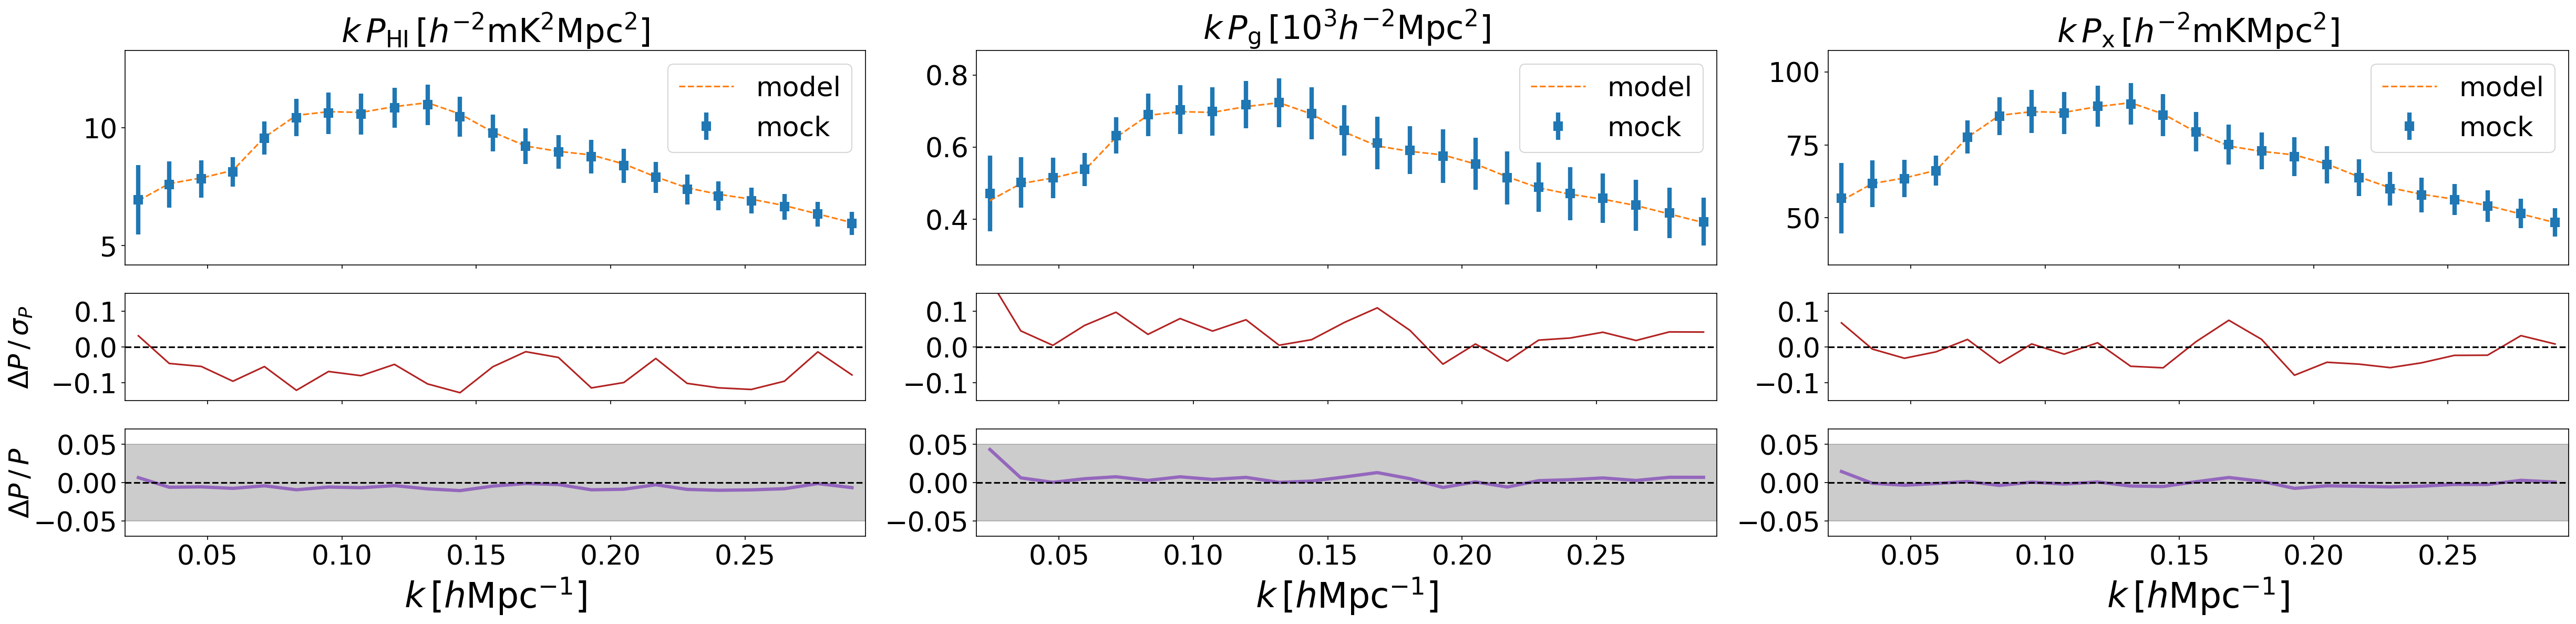

In [10]:
plt.rcParams['font.size'] = 25
fig,axes=plt.subplots(
    3,3,figsize=(40,8),sharex=True,
    height_ratios=[2,1,1],dpi=150,
    gridspec_kw={'wspace':0.15},
)
ratio_min,ratio_max = (-0.15,0.15)
pmockarr = [phimock1darr*1e6,pgmock1darr/1e3,pcrossmock1darr*1e3]
pmockarr = np.array(pmockarr) * Planck18.h**3
pmodelarr = [phimod1darr*1e6,pgmod1darr/1e3,pcrossmod1darr*1e3]
pmodelarr = np.array(pmodelarr)[:,0] * Planck18.h**3
#titlearr = [r'HI power',r'Galaxy power',r'Cross power']
titlearr= [
    r'$k\,P_{\rm HI}\,[ h^{-2} {\rm mK^2 Mpc^2}]$',
    r'$k\,P_{\rm g}\,[ 10^3 h^{-2}{\rm Mpc^2}]$',
    r'$k\,P_{\rm x}\,[h^{-2} {\rm mKMpc^2}]$',
]
for i in range(3):
    pdatad = pmockarr[i]
    pmodd = pmodelarr[i]
    axes[0,i].errorbar(
        keff,
        pdatad.mean(axis=0) * keff,
        yerr=pdatad.std(axis=0) * keff,
        label="mock",
        ls='None',
        elinewidth=4,
        marker='s',
        markersize=8,
    )
    axes[0,i].plot(keff, pmodd * keff, label="model", ls="--")
    axes[0,i].set_ylim((pmodd * keff).min() * 0.7, (pmodd * keff).max() * 1.2)
    axes[0,i].legend()
    #axes[0,i].set_ylabel(ylabelarr[i],labelpad=30)
    axes[0,i].set_title(titlearr[i])
    axes[1,i].plot(
        keff,
        (pdatad.mean(axis=0)- pmodd) / (pdatad.std(axis=0)),
        #yerr=(pdatad.std(axis=0)) / (pmodd) / np.sqrt(len(pdatad)),
        color='firebrick',
    )
    axes[1,i].axhline(0, color="black", ls="--")
    #axes[1,i].fill_between(
    #    np.linspace(keff.min()-0.005,keff.max()+0.005,100), 
    #    -0.05, 0.05, color="black", alpha=0.2,
    #)
    #axes[1,i].fill_between(
    #    np.linspace(keff.min()-0.005,keff.max()+0.005,100), 
    #    -0.02, 0.02, color="black", alpha=0.2,
    #)
    axes[1,i].set_xlim(keff.min()-0.005,keff.max()+0.005)
    axes[1,i].set_ylim(ratio_min,ratio_max)
    if i == 0:
        axes[1,i].set_ylabel(r'$\Delta P \, / \,\sigma_P$',labelpad=15)

    axes[2,i].plot(
        keff,
        (pdatad.mean(axis=0)) / (pmodd) - 1,
        lw=3,
        color='C4',
        #yerr=(pdatad.std(axis=0)) / (pmodd),
    )
    axes[2,i].axhline(0, color="black", ls="--")
    axes[2,i].fill_between(
        np.linspace(keff.min() - 0.005, keff.max() + 0.005, 100),
        -0.05,
        0.05,
        color="black",
        alpha=0.2,
    )
    axes[2,i].set_xlim(keff.min() - 0.005, keff.max() + 0.005)
    axes[2,i].set_ylim(-0.07, 0.07)
    axes[2,i].set_xlabel(r'$k\,[h{\rm Mpc^{-1}}]$', fontsize=32)
    if i == 0:
        axes[2,i].set_ylabel(r'$\Delta P \, / \,P$',labelpad=-1)
plt.savefig('plots/mock_validation_1d.pdf',dpi=150, bbox_inches = "tight")